# GSNN training-set evaluation

Evaluates each checkpoint written by the train workflow rule `pretrain_gsnn` (`pretrained_model_{sample}.pt` + `dxdt_scale_{sample}.pt`) on the **same** dX/dt supervision used during training.

- **Per model**: one row per `sample_*` (bootstrap / trajectory sample) with global MSE over all output nodes and summary gene-level statistics.
- **Per gene**: MSE, MAE, and R² on the scaled dX/dt target for each trajectory-mapped gene (same columns the trainer supervises).

Paths are read from `workflow/train/config.yaml` (`run_id`, `dirs.runs`, `dirs.preds`). Results are written under `{runs}/{run_id}/pretrain/eval_train/`.

In [1]:
from __future__ import annotations

import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader

from lincs_gsnn.data.DXDTDataset import DXDTDataset

REPO_ROOT = Path("..").resolve()
CONFIG_PATH = REPO_ROOT / "workflow" / "train" / "config.yaml"
if not CONFIG_PATH.is_file():
    REPO_ROOT = Path.cwd()
    CONFIG_PATH = REPO_ROOT / "workflow" / "train" / "config.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

RUN_ID = cfg["run_id"]
PREDS_ROOT = Path(cfg["dirs"]["preds"])
RUNS_ROOT = Path(cfg["dirs"]["runs"])
PRETRAIN_DIR = RUNS_ROOT / RUN_ID / cfg["dirs"]["pretrain"]
BIONET_PATH = RUNS_ROOT / RUN_ID / cfg["dirs"]["bio_network"] / "bionetwork.pt"

BATCH_SIZE = 256
NUM_WORKERS = 4

samples = sorted(
    Path(p).name for p in glob.glob(str(PREDS_ROOT / "sample_*")) if Path(p).is_dir()
)
print(f"run_id={RUN_ID}")
print(f"pretrain_dir={PRETRAIN_DIR}")
print(f"n_samples={len(samples)}")

run_id=all_edges_hi_conf_network_01
pretrain_dir=/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/all_edges_hi_conf_network_01/pretrain
n_samples=50


In [2]:
def load_run_assets():
    data = torch.load(BIONET_PATH, map_location="cpu", weights_only=False)
    dxdt_meta = pd.read_csv(PREDS_ROOT / "dxdt_meta.csv")
    src_gene_names = pd.read_csv(PREDS_ROOT / "gene_names.csv")["gene_names"].astype(str).tolist()
    pert_ids_net = [x.split("__", 1)[1] for x in data.node_names_dict["input"] if "DRUG__" in x]
    dxdt_meta = dxdt_meta[dxdt_meta["pert_id"].isin(pert_ids_net)].reset_index(drop=True)
    return data, dxdt_meta, src_gene_names


def build_dataset(sample: str, dxdt_meta, data, src_gene_names, scale: float) -> DXDTDataset:
    obs_dir = str(PREDS_ROOT / sample / "obs")
    dxdt_dir = str(PREDS_ROOT / sample / "dxdt")
    return DXDTDataset(
        dxdt_meta,
        input_names=data.node_names_dict["input"],
        output_names=data.node_names_dict["output"],
        src_names=src_gene_names,
        obs_dir=obs_dir,
        dxdt_dir=dxdt_dir,
        scale=scale,
    )


@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            print(f'progress: {batch_idx} / {len(loader)}', end='\r')
            if len(batch) == 3:
                X, y, _ = batch
            else:
                X, y = batch
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            ys.append(y.cpu().detach())
            ps.append(pred.cpu().detach())
    return torch.cat(ys, dim=0), torch.cat(ps, dim=0)


def per_gene_table(y: torch.Tensor, p: torch.Tensor, gene_cols: np.ndarray, gene_labels: list[str]) -> pd.DataFrame:
    y_np = y.numpy()
    p_np = p.numpy()
    rows = []
    for col, gsym in zip(gene_cols, gene_labels):
        yt = y_np[:, col]
        pr = p_np[:, col]
        mse = mean_squared_error(yt, pr)
        mae = mean_absolute_error(yt, pr)
        r2 = np.nan if np.var(yt) < 1e-12 else r2_score(yt, pr)
        rows.append({"gene": gsym, "mse": mse, "mae": mae, "r2": r2, "n_examples": len(yt)})
    return pd.DataFrame(rows)


def evaluate_sample(sample: str, data, dxdt_meta, src_gene_names, device) -> tuple[pd.DataFrame, dict]:
    model_path = PRETRAIN_DIR / f"pretrained_model_{sample}.pt"
    scale_path = PRETRAIN_DIR / f"dxdt_scale_{sample}.pt"
    if not model_path.is_file():
        raise FileNotFoundError(model_path)
    scale_t = torch.load(scale_path, map_location="cpu", weights_only=False)
    scale = float(scale_t.flatten()[0])

    ds = build_dataset(sample, dxdt_meta, data, src_gene_names, scale)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )

    model = torch.load(model_path, map_location=device, weights_only=False)
    model = model.to(device)
    y, pred = predict_all(model, loader, device)

    mse_full = mean_squared_error(y.numpy().ravel(), pred.numpy().ravel())

    gidx = torch.unique(ds.dst2_ixs, sorted=True).numpy()
    out_names = data.node_names_dict["output"]
    gene_labels = [out_names[int(i)].split("__", 1)[1] for i in gidx]
    gdf = per_gene_table(y, pred, gidx, gene_labels)
    gdf.insert(0, "sample_id", sample)

    summary = {
        "sample_id": sample,
        "n_examples": int(y.shape[0]),
        "n_genes_scored": int(len(gidx)),
        "mse_full_output": mse_full,
        "mse_gene_mean": float(gdf["mse"].mean()),
        "mae_gene_mean": float(gdf["mae"].mean()),
        "r2_gene_mean": float(np.nanmean(gdf["r2"].to_numpy())),
        "r2_gene_median": float(np.nanmedian(gdf["r2"].to_numpy())),
    }
    return gdf, summary

In [3]:
from IPython.display import display

data, dxdt_meta, src_gene_names = load_run_assets()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, n_meta_rows={len(dxdt_meta)}")

per_gene_parts: list[pd.DataFrame] = []
per_model_rows: list[dict] = []
missing = [s for s in samples if not (PRETRAIN_DIR / f"pretrained_model_{s}.pt").is_file()]
if missing:
    print("Skipping samples without checkpoints:", missing[:8], "..." if len(missing) > 8 else "")

for s in samples:
    if s in missing:
        continue
    print(f"evaluating {s}...")
    gdf, summ = evaluate_sample(s, data, dxdt_meta, src_gene_names, device)
    per_gene_parts.append(gdf)
    per_model_rows.append(summ)

if not per_gene_parts:
    per_gene = pd.DataFrame()
    per_model = pd.DataFrame()
    print("No checkpoints evaluated.")
else:
    per_gene = pd.concat(per_gene_parts, ignore_index=True)
    per_model = pd.DataFrame(per_model_rows)
    OUT_DIR = PRETRAIN_DIR / "eval_train"
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    per_gene.to_csv(OUT_DIR / "per_gene_train_metrics.csv", index=False)
    per_model.to_csv(OUT_DIR / "per_model_train_metrics.csv", index=False)
    print("wrote:", OUT_DIR)

display(per_model)

device=cuda, n_meta_rows=26400
evaluating sample_0...


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


evaluating sample_1...
evaluating sample_10...
evaluating sample_11...
evaluating sample_12...
evaluating sample_13...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa594b90900>
Traceback (most recent call last):
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa594b90900>
Traceback (most recent call last):


...

evaluating sample_17...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa594b90900>
Traceback (most recent call last):
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    

assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa594b90900>
 Traceback (most recent call last):
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
              ^^^self._shutdown_workers()
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():
    ^^^  ^^^^^^^^^^^^ ^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7fa594b90900>^
Traceback (most recent call last):
  File "/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
^^^    self._shutdown_workers()^^^^
^^^^  File "/home/exacloud/

evaluating sample_18...
evaluating sample_19...
evaluating sample_2...
evaluating sample_20...
evaluating sample_21...
evaluating sample_22...
evaluating sample_23...
evaluating sample_24...
evaluating sample_25...
evaluating sample_26...
evaluating sample_27...
evaluating sample_28...
evaluating sample_29...
evaluating sample_3...
evaluating sample_30...
evaluating sample_31...
evaluating sample_32...
evaluating sample_33...
evaluating sample_34...
evaluating sample_35...
evaluating sample_36...
evaluating sample_37...
evaluating sample_38...
evaluating sample_39...
evaluating sample_4...
evaluating sample_40...
evaluating sample_41...
evaluating sample_42...
evaluating sample_43...
evaluating sample_44...
evaluating sample_45...
evaluating sample_46...
evaluating sample_47...
evaluating sample_48...
evaluating sample_49...
evaluating sample_5...
evaluating sample_6...
evaluating sample_7...
evaluating sample_8...
evaluating sample_9...
wrote: /home/exacloud/gscratch/mcweeney_lab/evan

,sample_id,n_examples,n_genes_scored,mse_full_output,mse_gene_mean,mae_gene_mean,r2_gene_mean,r2_gene_median
0,sample_0,26400,978,0.451794,0.451793,0.344419,0.526571,0.841364
1,sample_1,26400,978,0.464209,0.464210,0.345951,0.515578,0.810892
2,sample_10,26400,978,0.461092,0.461092,0.335394,0.544344,0.859230
3,sample_11,26400,978,0.463991,0.463992,0.326499,0.546779,0.877887
4,sample_12,26400,978,0.490769,0.490769,0.354647,0.528586,0.845178
5,sample_13,26400,978,0.467221,0.467220,0.349640,0.524140,0.834158
6,sample_14,26400,978,0.457946,0.457947,0.334113,0.537820,0.863423
7,sample_15,26400,978,0.488243,0.488243,0.361189,0.516080,0.821763
8,sample_16,26400,978,0.467975,0.467976,0.342668,0.517536,0.814614
9,sample_17,26400,978,0.461260,0.461261,0.347074,0.519068,0.821272


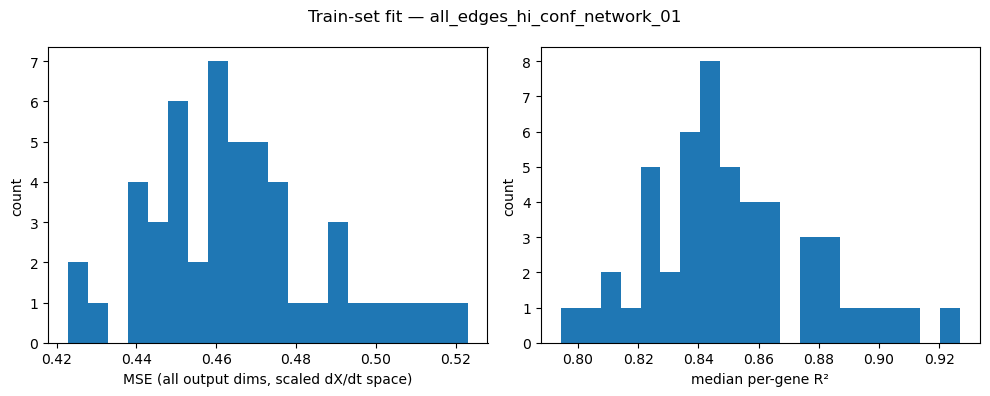

In [4]:
import matplotlib.pyplot as plt

if per_model.empty:
    print("No models evaluated; skip plots.")
else:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].hist(per_model["mse_full_output"], bins=min(20, max(5, len(per_model))))
    ax[0].set_xlabel("MSE (all output dims, scaled dX/dt space)")
    ax[0].set_ylabel("count")
    ax[1].hist(per_model["r2_gene_median"].dropna(), bins=min(20, max(5, len(per_model))))
    ax[1].set_xlabel("median per-gene R²")
    ax[1].set_ylabel("count")
    fig.suptitle(f"Train-set fit — {RUN_ID}")
    fig.tight_layout()
    plt.show()

In [5]:
per_model.head()

,sample_id,n_examples,n_genes_scored,mse_full_output,mse_gene_mean,mae_gene_mean,r2_gene_mean,r2_gene_median
0,sample_0,26400,978,0.451794,0.451793,0.344419,0.526571,0.841364
1,sample_1,26400,978,0.464209,0.464210,0.345951,0.515578,0.810892
2,sample_10,26400,978,0.461092,0.461092,0.335394,0.544344,0.859230
3,sample_11,26400,978,0.463991,0.463992,0.326499,0.546779,0.877887
4,sample_12,26400,978,0.490769,0.490769,0.354647,0.528586,0.845178


In [6]:
per_model.r2_gene_mean.mean() 

0.5329256819276966

In [7]:
per_model.r2_gene_mean.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05    0.514325
0.25    0.524128
0.50    0.531282
0.75    0.539985
0.95    0.556429
Name: r2_gene_mean, dtype: float64

In [10]:
function_nodes = data.node_names_dict["function"] 
output_nodes = data.node_names_dict["output"] 

isolates = [] 
for node in output_nodes:
    gene = node.split("__", 1)[1] 
    rna_gene = f"RNA__{gene}"
    if rna_gene not in function_nodes:
        isolates.append(node)
len(isolates)



0

In [11]:
per_gene = pd.read_csv(OUT_DIR / "per_gene_train_metrics.csv")
per_gene.head()

,sample_id,gene,mse,mae,r2,n_examples
0,sample_0,GNPDA1,0.913365,0.583129,0.001694,26400
1,sample_0,CDH3,0.061565,0.165750,0.801084,26400
2,sample_0,HDAC6,0.080664,0.191610,0.937004,26400
3,sample_0,PARP2,1.469457,0.722599,0.026169,26400
4,sample_0,MAMLD1,0.202449,0.284211,0.025762,26400


In [13]:
per_gene = per_gene.groupby("gene").mean({"r2": "r2_mean", "mse": "mse_mean", "mae": "mae_mean", "n_examples": "n_examples_mean"}).reset_index()
per_gene.head() 

,gene,mse,mae,r2,n_examples
0,AARS,1.280054,0.662034,0.016940,26400.0
1,ABCB6,0.865638,0.586753,0.019443,26400.0
2,ABCC5,0.090179,0.197743,0.870533,26400.0
3,ABCF1,0.728794,0.547020,0.018828,26400.0
4,ABCF3,0.726506,0.529411,0.019070,26400.0


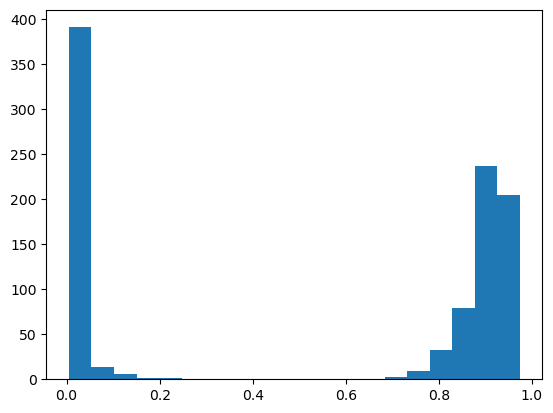

In [15]:
plt.figure() 
plt.hist(per_gene.r2, bins=20) 
plt.show() 


In [16]:
(per_gene.r2 < 0.1).sum(), per_gene.gene.nunique() 

(405, 978)

In [18]:
(per_gene.r2 > 0.75).sum(), per_gene.gene.nunique() 

(562, 978)

In [25]:
((0.1 < per_gene.r2) & (per_gene.r2 < 0.75)).sum(), per_gene.gene.nunique() 

(11, 978)